In [ ]:
import pandas as pd

# Load the dataset
try:
    df = pd.read_csv('Data.csv') # Changed 'data.csv' to 'Data.csv'
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'Data.csv' not found. Please ensure the file is uploaded to your Colab environment.")
    df = None

if df is not None:
    # Display the first 5 rows of the dataframe
    print("\n--- First 5 rows ---")
    print(df.head())

    # Display basic information about the dataframe (data types, non-null values)
    print("\n--- Data Info ---")
    df.info()

    # Display descriptive statistics for numerical columns
    print("\n--- Descriptive Statistics ---")
    print(df.describe())

    # Check for missing values
    print("\n--- Missing Values ---")
    print(df.isnull().sum())

    # Identify potential date/time columns for financial data
    date_columns = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
    if date_columns:
        print(f"\nPotential date/time columns identified: {date_columns}")
        print("Consider converting these to datetime objects: `pd.to_datetime(df['column_name'])`")
    else:
        print("\nNo obvious date/time columns found. If your financial data has a time component, you might need to identify it manually.")


Dataset loaded successfully.

--- First 5 rows ---
   Marketing_Spend      R&D_Spend  Administration_Costs  Number_of_Employees  \
0     78035.323175   99884.430462          14796.767539                   54   
1    190389.289750   21779.595099          90742.526135                  141   
2    147738.818653   32628.019973          52998.975383                  219   
3    121738.404418  135797.586394          83513.459280                  366   
4     35423.634886   94900.068352          35404.712098                   71   

          Region        Revenue  
0  North America  100202.726641  
1  North America  111521.739997  
2  North America   90447.563754  
3  North America  146658.747291  
4           Asia   97992.465094  

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Marketing_Spend       200 non-null

In [ ]:
print("\n--- Converting 'Region' to numerical data ---")
# Convert 'Region' column into numerical data using one-hot encoding
df = pd.get_dummies(df, columns=['Region'], prefix='Region')

# Display the first 5 rows with the new numerical 'Region' columns
print("DataFrame after one-hot encoding 'Region':")
print(df.head())

# Display data types to confirm the change
print("\n--- Data Info after encoding ---")
df.info()


--- Converting 'Region' to numerical data ---


KeyError: "None of [Index(['Region'], dtype='object')] are in the [columns]"

### Distribution of Revenue

Let's start by looking at the distribution of the `Revenue` column using a histogram and a Kernel Density Estimate (KDE) plot. This will show us the frequency of different revenue values and the overall shape of their distribution.

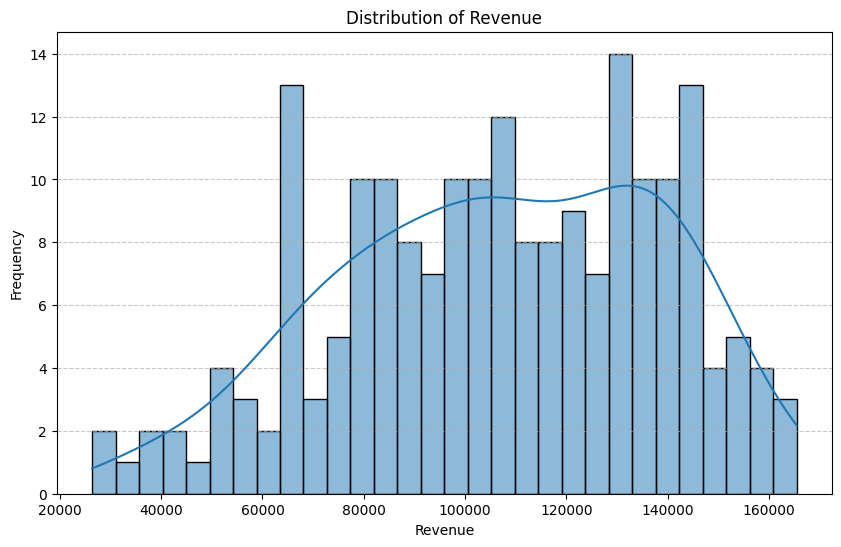

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Revenue'], kde=True, bins=30)
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Revenue Box Plot

A box plot will help us visualize the central tendency, spread, and potential outliers in the `Revenue` data.

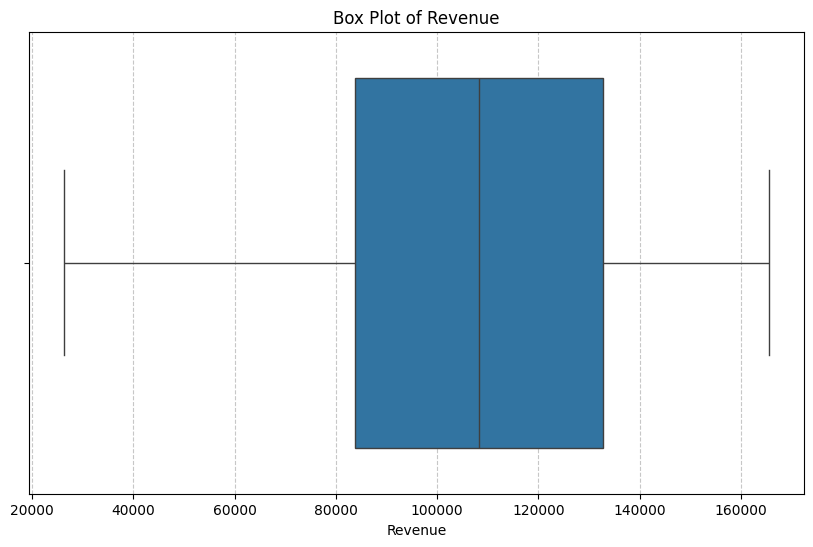

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Revenue'])
plt.title('Box Plot of Revenue')
plt.xlabel('Revenue')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Revenue Violin Plot

A violin plot combines the benefits of a box plot with a kernel density estimate, showing the distribution shape, median, and quartiles more comprehensively.

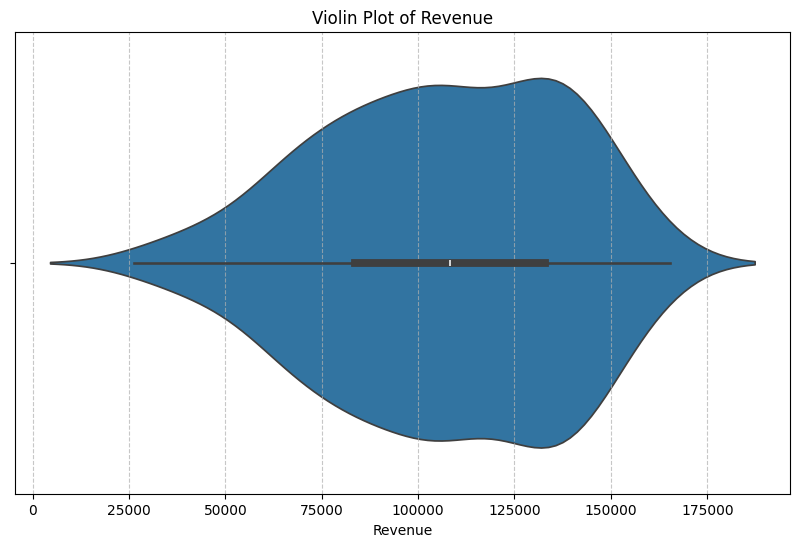

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=df['Revenue'])
plt.title('Violin Plot of Revenue')
plt.xlabel('Revenue')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Correlation Analysis

Let's visualize the correlation matrix to understand the linear relationships between `Revenue` and other numerical factors, as well as between the factors themselves. A heatmap provides a clear way to see these relationships.

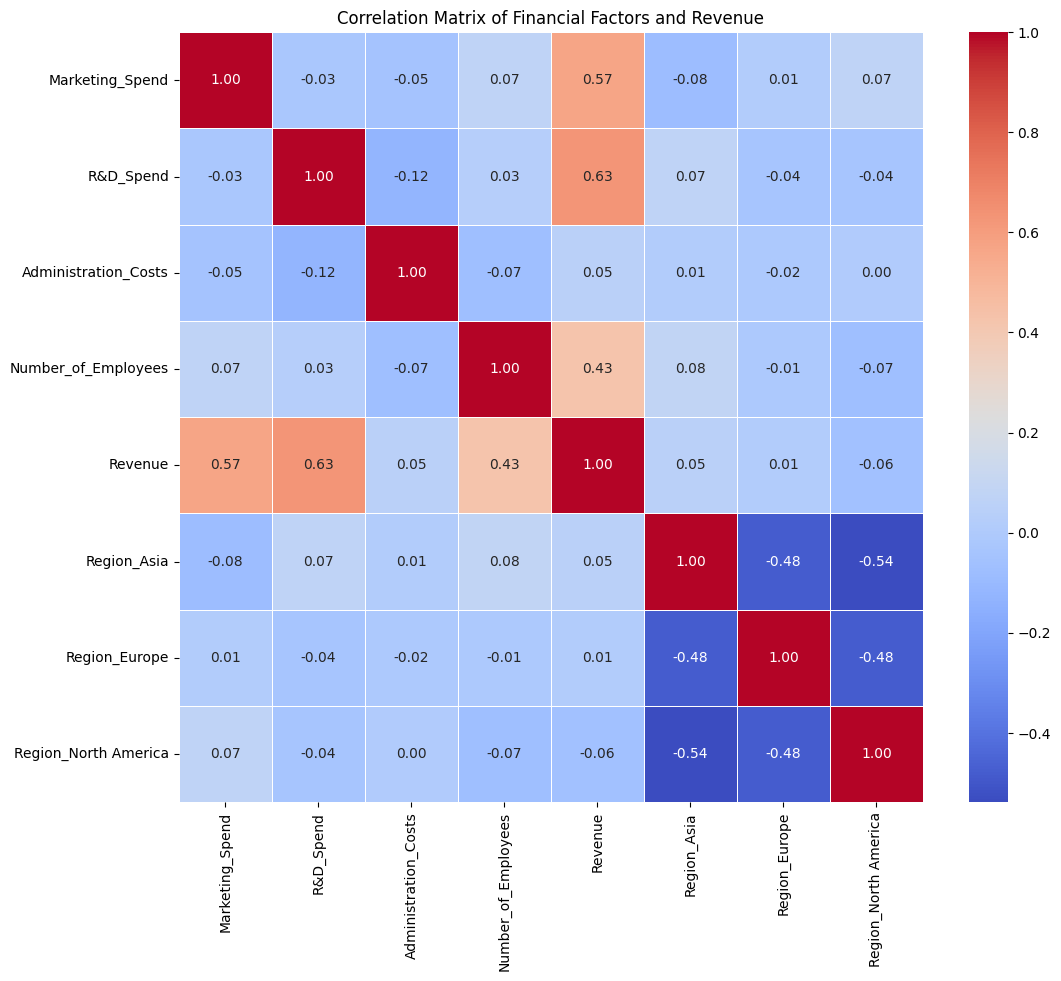

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Financial Factors and Revenue')
plt.show()

### R-squared Values for each Factor vs. Revenue

To quantify how much variance in `Revenue` is explained by each individual factor, we can calculate the R-squared value. For a simple linear relationship, R-squared is simply the square of the Pearson correlation coefficient between `Revenue` and each factor.

R-squared values for each factor explaining Revenue:
R&D_Spend               0.395777
Marketing_Spend         0.322941
Number_of_Employees     0.183957
Region_North America    0.003651
Region_Asia             0.002378
Administration_Costs    0.002335
Region_Europe           0.000147
Name: Revenue, dtype: float64


/tmp/ipykernel_4978/3189069788.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=r_squared_values.index, y=r_squared_values.values, palette='viridis')


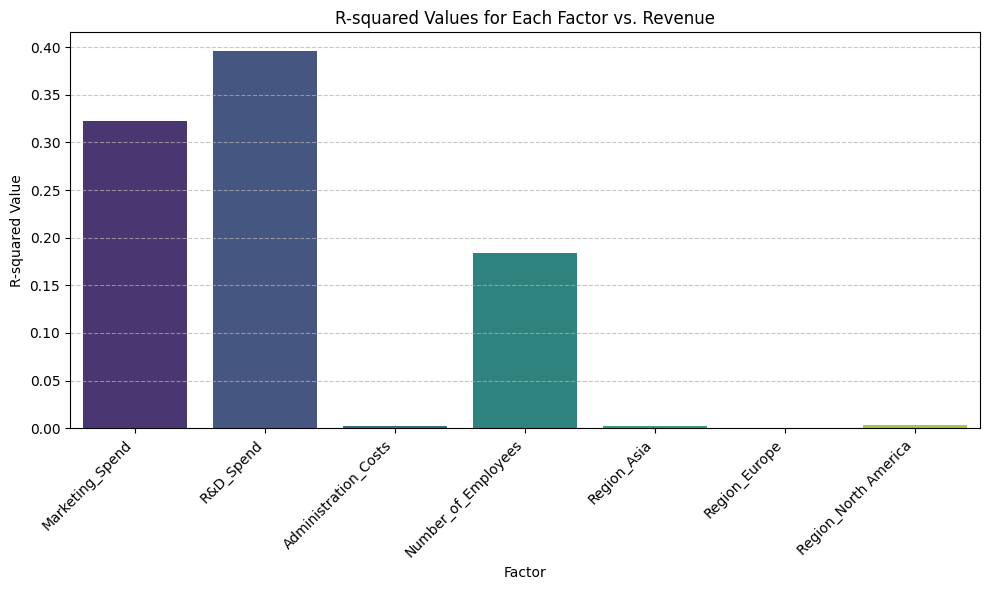

In [ ]:
import pandas as pd

# Calculate correlations of all numerical columns with 'Revenue'
revenue_correlations = df.corr(numeric_only=True)['Revenue']

# Remove 'Revenue' itself from the list of factors
revenue_correlations = revenue_correlations.drop('Revenue')

# Calculate R-squared values
r_squared_values = revenue_correlations**2

print("R-squared values for each factor explaining Revenue:")
print(r_squared_values.sort_values(ascending=False))

# You can also visualize these R-squared values
plt.figure(figsize=(10, 6))
sns.barplot(x=r_squared_values.index, y=r_squared_values.values, palette='viridis')
plt.title('R-squared Values for Each Factor vs. Revenue')
plt.xlabel('Factor')
plt.ylabel('R-squared Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Data Preparation for Machine Learning

Before training a machine learning model, it's crucial to split the data into training and testing sets. This allows us to evaluate how well our model generalizes to unseen data.

*   **Features (X)**: These are the independent variables that will be used to predict the target.
*   **Target (y)**: This is the dependent variable we want to predict (`Revenue`).

We will use `train_test_split` from `sklearn.model_selection` for this purpose.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Drop 'Revenue' from features as it is the target
# Also drop original 'Region' column if it still exists (though it should be one-hot encoded now)
# Exclude the one-hot encoded Region columns themselves if you only want to predict based on numerical spend/employee data,
# or include them if you want to see their effect.

X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Split the data into training and testing sets
# We'll use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Target training set shape: {y_train.shape}")
print(f"Target testing set shape: {y_test.shape}")

Training set shape: (160, 7)
Testing set shape: (40, 7)
Target training set shape: (160,)
Target testing set shape: (40,)


### Training an XGBoost Regressor Model

Now, let's train an XGBoost Regressor model on our training data. We'll use default parameters for now, and can tune them later for better performance if needed.

XGBoost Regressor model trained successfully!

Mean Squared Error (MSE) on Test Set: 161338215.60
R-squared (R2) Score on Test Set: 0.85


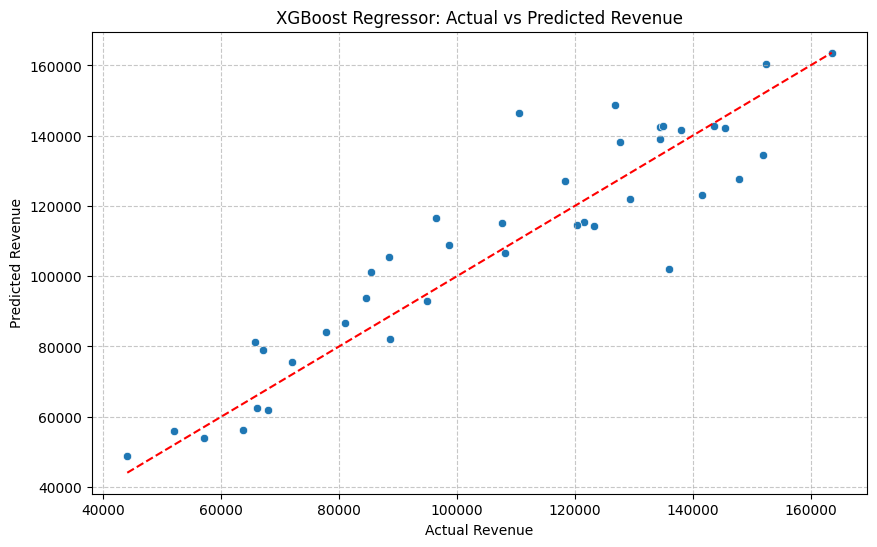

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', # For regression tasks
                             n_estimators=100,            # Number of boosting rounds
                             learning_rate=0.1,           # Step size shrinkage to prevent overfitting
                             random_state=42)

# Train the model on the training data
xgb_model.fit(X_train, y_train)

print("XGBoost Regressor model trained successfully!")

# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE) on Test Set: {mse:.2f}")
print(f"R-squared (R2) Score on Test Set: {r2:.2f}")

# You can also visualize the predictions vs actual values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Perfect prediction line
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('XGBoost Regressor: Actual vs Predicted Revenue')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Training a LightGBM Regressor Model

Let's try another popular gradient-boosting framework, LightGBM (Light Gradient Boosting Machine). LightGBM is often faster than XGBoost and can sometimes yield better performance, especially on larger datasets. We'll train a `LGBMRegressor` model and evaluate its performance.

### Training a Random Forest Regressor Model

Now, let's train a `RandomForestRegressor` model. Random Forests are ensemble methods that operate by constructing a multitude of decision trees at training time and outputting the mean prediction of the individual trees. They are known for their high accuracy, ability to handle non-linear relationships, and built-in feature importance selection.



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000435 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 224
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 7
[LightGBM] [Info] Start training from score 106552.808618
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

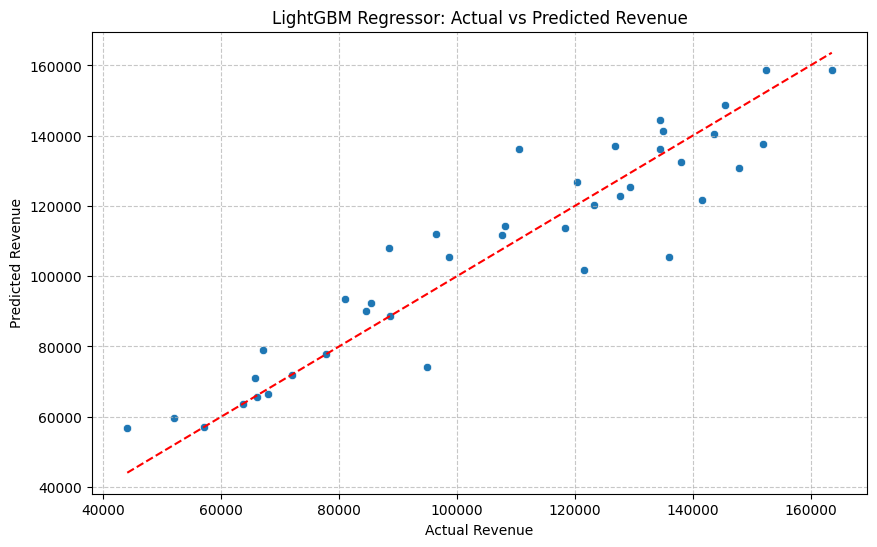

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the LightGBM Regressor model
lgbm_model = lgb.LGBMRegressor(objective='regression', # For regression tasks
                               n_estimators=100,       # Number of boosting rounds
                               learning_rate=0.1,      # Step size shrinkage
                               random_state=42)

# Train the model on the training data
lgbm_model.fit(X_train, y_train)

print("LightGBM Regressor model trained successfully!")

# Make predictions on the test set
y_pred_lgbm = lgbm_model.predict(X_test)

# Evaluate the model
mse_lgbm = mean_squared_error(y_test, y_pred_lgbm)
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print(f"\nMean Squared Error (MSE) on Test Set (LightGBM): {mse_lgbm:.2f}")
print(f"R-squared (R2) Score on Test Set (LightGBM): {r2_lgbm:.2f}")

# Visualize the predictions vs actual values for LightGBM
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lgbm)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Perfect prediction line
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('LightGBM Regressor: Actual vs Predicted Revenue')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Training a Random Forest Regressor Model

Now, let's train a `RandomForestRegressor` model. Random Forests are ensemble methods that operate by constructing a multitude of decision trees at training time and outputting the mean prediction of the individual trees. They are known for their high accuracy, ability to handle non-linear relationships, and built-in feature importance selection.

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Step 1: Load and preprocess the dataset
def load_and_preprocess(file_path):
    """
    Load dataset and prepare features and target.
    """
    df = pd.read_csv(file_path)

    # Separate features (X) and target (y)
    X = df.drop('Revenue', axis=1)
    y = df['Revenue']

    # Identify numerical and categorical columns
    numerical_cols = X.select_dtypes(include=np.number).columns
    categorical_cols = X.select_dtypes(include='object').columns

    # Create preprocessing pipelines for numerical and categorical features
    numerical_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Create a preprocessor using ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_cols),
            ('cat', categorical_transformer, categorical_cols)
        ])

    return X, y, preprocessor

# Step 2: Train the Linear Regression model
def train_model(X_train, y_train, preprocessor):
    """
    Train Linear Regression using a Pipeline.
    """
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])
    model.fit(X_train, y_train)
    return model

#Step 3: Evaluate model Performance
def evaluate_model(model, X_test, y_test):
    """
    Evaluate the trained model.
    """
    y_pred = model.predict(X_test)

    # Calculate MAE, RMSE, R Square
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    #Print Evaluation metrics
    print("\n--- Model Evaluation ---")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2) Score: {r2:.2f}")

#Step 4: Predict revenue for new input
def predict_revenue(model, user_input):
    """
    Predict revenue for a single user input
    """
    input_df = pd.DataFrame([user_input])
    predicted_revenue = model.predict(input_df)[0]
    print(f"\nPredicted Revenue for the given input: ${predicted_revenue:.2f}")
    return predicted_revenue

#Step 5: Main Program
def main():
    """
    Main execution flow.
    """
    file_path = "Data.csv"
    X, y, preprocessor = load_and_preprocess(file_path)

    #Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    #Train model
    model = train_model(X_train, y_train, preprocessor)
    print("Linear Regression model trained successfully!")

    # Evaluate model
    evaluate_model(model, X_test, y_test)

    # Accept user input in loop and predict revenue
    print("\n--- Prediction Example ---")
    # Example user input (ensure it matches the feature columns)
    sample_input = {
        'Marketing_Spend': 70000,
        'R&D_Spend': 90000,
        'Administration_Costs': 50000,
        'Number_of_Employees': 200,
        'Region': 'North America'
    }
    predict_revenue(model, sample_input)

if __name__ =="__main__":
    main()

Linear Regression model trained successfully!

--- Model Evaluation ---
Mean Absolute Error (MAE): 6648.40
Root Mean Squared Error (RMSE): 8363.06
R-squared (R2) Score: 0.93

--- Prediction Example ---

Predicted Revenue for the given input: $94753.19
